<a href="https://colab.research.google.com/github/Yugansh-Varshney/ANN-Classification-Churn-Prediction-Model/blob/main/DL_Lab2_Training_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 2 — Training an ANN with PyTorch
We take the same network from Lab 1 and actually train it, using PyTorch's built-in tools (no manual math).

## Step 1 — Setup

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("torch:", torch.__version__)


torch: 2.11.0+cpu


## Step 2 — Load and clean data
Same cleaning as Lab 1, just condensed here.

In [11]:
df = sns.load_dataset('titanic')

# drop columns we don't need
df = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone'])

# fill missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# encode categorical columns to numbers
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=False)

# scale numeric columns using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S
0,0,3,0,-0.565736,1,0,-0.502445,False,False,True
1,1,1,1,0.663861,1,0,0.786845,True,False,False
2,1,3,1,-0.258337,0,0,-0.488854,False,False,True
3,1,1,1,0.433312,1,0,0.420730,False,False,True
4,0,3,0,0.433312,0,0,-0.486337,False,False,True


## Step 3 — Split into train and test sets
We train on one part of the data, and test on data the model has never seen, to check if it actually learned something.

In [3]:
X = df.drop(columns=['survived']).values.astype(np.float32)
y = df['survived'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# convert to torch tensors (the format PyTorch works with)
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train).view(-1, 1)   # reshape to column vector

X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test).view(-1, 1)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Number of input features:", X_train.shape[1])


Train samples: 712
Test samples: 179
Number of input features: 9


## Step 4 — Build the model
Same architecture as Lab 1 (input -> hidden layer -> output), but now defined with PyTorch's built-in `nn.Linear` and `nn.Sigmoid` — no manual weight math needed.

In [4]:
n_features = X_train.shape[1]
n_hidden = 4

model = nn.Sequential(
    nn.Linear(n_features, n_hidden),   # input layer -> hidden layer
    nn.ReLU(),                         # activation for hidden layer
    nn.Linear(n_hidden, 1),            # hidden layer -> output layer
    nn.Sigmoid()                       # squashes output to (0,1) = probability of survival
)

print(model)


Sequential(
  (0): Linear(in_features=9, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)


## Step 5 — Loss function and optimizer
The loss function tells us how wrong the model is. The optimizer updates the weights to reduce that loss.

In [5]:
loss_fn = nn.BCELoss()   # binary cross-entropy loss, standard for yes/no predictions

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)   # Adam updates all weights for us


## Step 6 — Check the model before training
Just to see: with random weights, the model knows nothing yet.

In [6]:
with torch.no_grad():
    preds = model(X_train)
    initial_loss = loss_fn(preds, y_train)

print("Loss before training:", initial_loss.item())
print("First 5 predictions:", preds[:5].flatten())
print("First 5 actual labels:", y_train[:5].flatten())


Loss before training: 0.6913635730743408
First 5 predictions: tensor([0.4413, 0.4548, 0.4702, 0.4723, 0.5179])
First 5 actual labels: tensor([0., 0., 0., 0., 0.])


## Step 7 — Train the model
This is the core loop: predict -> compare to real answer -> update weights. Repeated many times (epochs).

In [7]:
n_epochs = 100
losses = []

for epoch in range(n_epochs):
    # forward pass: get predictions
    preds = model(X_train)

    # compute how wrong we are
    loss = loss_fn(preds, y_train)

    # backward pass: figure out how to adjust each weight
    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # compute new gradients
    optimizer.step()        # update the weights

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")


Epoch 0: loss = 0.6914
Epoch 10: loss = 0.6530
Epoch 20: loss = 0.6295
Epoch 30: loss = 0.5791
Epoch 40: loss = 0.5328
Epoch 50: loss = 0.4898
Epoch 60: loss = 0.4584
Epoch 70: loss = 0.4389
Epoch 80: loss = 0.4309
Epoch 90: loss = 0.4270


## Step 8 — Plot the loss curve
Watch the loss go down over training — this means the model is learning.

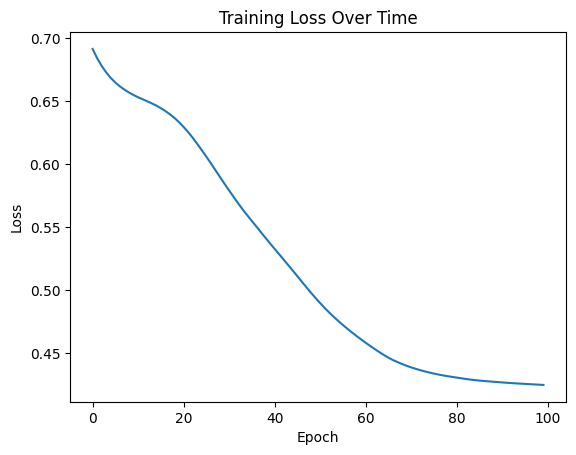

In [8]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.show()


## Step 9 — Check accuracy on test data
Test data was never seen during training, so this tells us how well the model actually learned (not just memorized).

In [9]:
with torch.no_grad():
    test_preds = model(X_test)
    test_preds_labels = (test_preds > 0.5).float()   # convert probability to 0 or 1

    accuracy = (test_preds_labels == y_test).float().mean()

print("Test accuracy:", accuracy.item())


Test accuracy: 0.8100558519363403


## Step 10 — Try changing things
Run the training loop again after changing one of these, and see what happens to the loss curve and accuracy:
- `n_hidden` (try 2, 8, 16)
- `lr` in the optimizer (try 0.1, 0.001)
- `n_epochs` (try 20, 300)